
# SAFOD AWD experiment: solid-Earth tides as a small-signal benchmark

## Purpose

This notebook asks a deliberately limited question:

> **How does the smallest plausible solid-Earth-tide velocity response compare with the empirical change-detection capability of the 2026 accelerated weight-drop (AWD) experiment?**

It is **not** an attempt to claim that the AWD experiment detected an Earth-tide signal. The AWD source was repeated, but it was not a phase-locked continuous source like the De Fazio et al. (1973) experiment, nor was it as stable and densely sampled as the active-source system used by Niu et al. (2008). Niu et al. did not conduct a dedicated search for a tidal signal; they modeled the expected tidal stress as a detectability check and concluded that the associated travel-time response should be below their measurement precision.

The tide is used here as a physically meaningful example of a signal that is much smaller than the current AWD detection threshold.

## Main conclusion

- The AWD data recover a stable coherent moveout observable after alignment and stacking.

- Individual drops nevertheless show variability in timing, amplitude, and signal-to-noise ratio.

- Blind injection–recovery gives an empirical two-sided 95% zero-injection threshold of approximately

  $$
  3.25 \times 10^{-3}
  =
  0.325\%.
  $$

- The smallest tested change with at least 95% correct-sign recovery in both directions is

  $$
  1.0 \times 10^{-2}
  =
  1\%.
  $$

- A SAFOD-relevant Earth-tide response scale based on Niu et al. (2008) is

  $$
  \left(2.4 \times 10^{-7}\ \mathrm{Pa}^{-1}\right)
  \left(240\ \mathrm{Pa}\right)
  =
  5.76 \times 10^{-5}
  =
  0.00576\%.
  $$

The Niu-scale response is therefore smaller than the measured single-burst null threshold by a factor of approximately

$$
\frac{3.25 \times 10^{-3}}
     {5.76 \times 10^{-5}}
\approx 56,
$$

and smaller than the lowest reliably recovered tested change by a factor of approximately

$$
\frac{1.0 \times 10^{-2}}
     {5.76 \times 10^{-5}}
\approx 174.
$$

Even under the idealized assumption that measurement uncertainty decreases as
\(N^{-1/2}\), combining all 46 paired burst stacks would give a projected
threshold of

$$
\frac{3.25 \times 10^{-3}}{\sqrt{46}}
\approx
4.79 \times 10^{-4}
=
0.0479\%,
$$

which remains approximately eight times larger than the Niu-scale response of
\(0.00576\%\).

## Recommended framing

> The repeated AWD experiment establishes an empirical sensitivity limit for the selected DAS apparent-moveout observable. Solid-Earth tides provide a useful small-signal benchmark: a SAFOD-relevant response scale inferred from Niu et al. (2008) lies well below the demonstrated AWD detection threshold. We therefore do not interpret 24-hour-timescale variability in the AWD delay series as a resolved tidal response.



# 1. Why source repeatability is central

De Fazio et al. (1973) explicitly contrasted their continuous, fixed-frequency source with transient repeated explosions. Their phase-monitoring strategy was designed so that precision was controlled mainly by oscillator and instrument stability; they noted that transient-source measurements are limited by arrival-time uncertainty and imperfect source repeatability.

Niu et al. (2008) used a highly repeatable active source at SAFOD that fired four times per second. By repeatedly stacking the source records, they produced one high-signal-to-noise-ratio record approximately every 45 minutes and reported a fractional-velocity detection threshold of about

$$
1.1 \times 10^{-5}
=
0.0011\%.
$$

They did not present a dedicated tidal-detection analysis. Instead, they calculated the expected solid-Earth tidal stress during the experiment and combined it with their measured velocity–stress sensitivity to estimate the corresponding travel-time perturbation. They concluded that the predicted tidal response was comparable to their measurement error and therefore unlikely to be detectable.

The AWD experiment serves a different purpose. It provides a repeated impulsive source with substantial energy and good stacked repeatability, but not a continuously phase-locked source. The figure below is therefore the starting point for any detectability argument.


### AWD repeatability hierarchy

![AWD repeatability hierarchy: stable after stacking, variable drop by drop](awd_clean/fig12_repeatability_publication.png)


**Interpretation of the repeatability figure**

- **Panel A:** the selected moveout waveform is often much more correlated than an equal-duration noise window, so the coherent mode is genuinely present in many individual drops.
- **Panel B:** most relative delays are close to zero, but there are millisecond-scale outliers.
- **Panel C:** individual-drop amplitude varies appreciably.
- **Panel D:** beam SNR varies strongly, and some individual drops are weak.
- **Panel E:** leave-one-burst-out burst stacks are highly correlated, showing that stacking produces a stable reference waveform.
- **Panel F:** independent substacks converge as more drops are included.

The correct summary is therefore:

> **The AWD source is repeatable enough to recover a stable stacked observable, but drop-to-drop source variability limits precision time-lapse measurements.**

“Repeated source” and “precision-repeatable source” are not the same statement.



# 2. Empirical AWD change-detection limit

The blind injection–recovery test is the strongest evidence for what the current experiment can resolve. It injects known apparent-velocity changes into real burst observations and recovers them without using the injection label.

This result is preferable to estimating precision from sample rate, nominal bandwidth, or a theoretical correlation formula because it includes the actual source variability, noise, waveform distortion, and estimator behavior present in the experiment.


### Nano blind injection–recovery

![Blind injection–recovery for the Nano apparent-moveout observable](awd_clean/nano_dvv_injection_recovery.png)

The two quantities used below are deliberately kept distinct:

1. **Empirical 95% null threshold**

   $$
   \left|\frac{\Delta v_{\rm app}}{v_{\rm app}}\right|
   \approx 3.25 \times 10^{-3}
   $$

   This is the two-sided range containing approximately 95% of zero-injection results after median calibration.

2. **Demonstrated high-reliability tested level**

   $$
   \left|\frac{\Delta v_{\rm app}}{v_{\rm app}}\right|
   = 1.0 \times 10^{-2}
   $$

   This is the smallest *tested* magnitude for which both positive and negative injections achieved at least 95% correct-sign recovery.

> **Note:** The second value is not necessarily the true mathematical detection limit; it is the floor of the tested injection grid that satisfied the stated reliability criterion. The first value characterizes the zero-change scatter.

# 3. What the solid-Earth-tide calculation does

The Moon and Sun exert spatially varying gravitational attraction across Earth. Because the near side, center, and far side are accelerated differently, the solid Earth deforms elastically.

This notebook retains a transparent first-pass calculation of the **degree-2 tide-generating potential**:

$$
W_b(t)
=
\frac{G M_b}{D_b(t)^3}\,
R_E^2\,
P_2\!\left[\cos\theta_b(t)\right],
\qquad
P_2(x)
=
\frac{3x^2-1}{2}.
$$

where \(b\) is the Sun or Moon, \(D_b\) is its distance from Earth, and \(\theta_b\) is its zenith angle at SAFOD.

The potential is converted to a scalar surface areal-strain proxy using quasi-static PREM Love numbers:

$$
\varepsilon_{A,\mathrm{proxy}}(t)
=
\left(2h_2 - 6l_2\right)
\frac{W_{\rm Sun}(t)+W_{\rm Moon}(t)}{gR_E}.
$$

The factor \(2h_2-6l_2\) combines the degree-2 radial and horizontal deformation contributions. The values used here,

$$
h_2 = 0.603741,
\qquad
l_2 = 0.084010,
$$

are the quasi-static PREM values reported by Métivier and Conrad (2008).

## What this quantity is

- an approximate **surface horizontal areal-strain** history;
- a useful first-pass estimate of tide timing and strain scale;
- a unitless template that can be compared with an observed time series.

## What it is not

- the full strain tensor at 864 m or 3 km depth;
- fault-normal or fault-shear stress;
- a pore-pressure prediction;
- a path-integrated seismic-velocity response;
- a calibrated prediction of \(\delta v/v\).

The compact Sun/Moon ephemerides below are suitable for an explanatory first pass, not precision tidal analysis. A publishable traction calculation should use a validated tide package and document body tides, ocean loading, atmospheric loading, depth, and projection conventions.

In [ ]:

from datetime import datetime, timedelta, timezone
import numpy as np

# SAFOD and experiment window
LATITUDE_DEG = 35.9746
LONGITUDE_DEG = -120.5516
START_UTC = datetime(2026, 6, 16, 23, 48, tzinfo=timezone.utc)
END_UTC = datetime(2026, 6, 17, 23, 44, tzinfo=timezone.utc)
SAMPLE_MINUTES = 1

# Physical constants
G = 6.674e-11
EARTH_RADIUS_M = 6.371e6
SURFACE_GRAVITY_M_S2 = 9.81
MOON_MASS_KG = 7.342e22
SUN_MASS_KG = 1.989e30
ASTRONOMICAL_UNIT_M = 1.495978707e11

# Quasi-static degree-2 PREM Love numbers
H2 = 0.603741
L2 = 0.084010
AREAL_LOVE_FACTOR = 2.0 * H2 - 6.0 * L2

def datetime_range(start, end, step_minutes):
    count = int((end - start).total_seconds() // (60.0 * step_minutes))
    return [start + timedelta(minutes=step_minutes * i) for i in range(count + 1)]

def julian_date(times):
    unix_seconds = np.array([t.timestamp() for t in times], dtype=float)
    return unix_seconds / 86400.0 + 2440587.5

def sun_position(jd):
    # Compact approximate solar ephemeris: right ascension, declination, distance.
    d = jd - 2451545.0
    mean_longitude = np.deg2rad((280.460 + 0.9856474 * d) % 360.0)
    mean_anomaly = np.deg2rad((357.528 + 0.9856003 * d) % 360.0)
    ecliptic_longitude = (
        mean_longitude
        + np.deg2rad(1.915) * np.sin(mean_anomaly)
        + np.deg2rad(0.020) * np.sin(2.0 * mean_anomaly)
    )
    distance_au = (
        1.00014
        - 0.01671 * np.cos(mean_anomaly)
        - 0.00014 * np.cos(2.0 * mean_anomaly)
    )
    obliquity = np.deg2rad(23.4393 - 3.563e-7 * d)
    ra = np.arctan2(
        np.cos(obliquity) * np.sin(ecliptic_longitude),
        np.cos(ecliptic_longitude),
    )
    dec = np.arcsin(np.sin(obliquity) * np.sin(ecliptic_longitude))
    return ra, dec, distance_au * ASTRONOMICAL_UNIT_M

def moon_position(jd):
    # Compact low-precision lunar ephemeris for an explanatory first pass.
    d = jd - 2451543.5
    node = np.deg2rad((125.1228 - 0.0529538083 * d) % 360.0)
    inclination = np.deg2rad(5.1454)
    perigee = np.deg2rad((318.0634 + 0.1643573223 * d) % 360.0)
    semimajor_axis = 60.2666
    eccentricity = 0.054900
    mean_anomaly = np.deg2rad((115.3654 + 13.0649929509 * d) % 360.0)

    eccentric_anomaly = mean_anomaly.copy()
    for _ in range(3):
        eccentric_anomaly -= (
            eccentric_anomaly
            - eccentricity * np.sin(eccentric_anomaly)
            - mean_anomaly
        ) / (1.0 - eccentricity * np.cos(eccentric_anomaly))

    x_orbit = semimajor_axis * (np.cos(eccentric_anomaly) - eccentricity)
    y_orbit = (
        semimajor_axis
        * np.sqrt(1.0 - eccentricity**2)
        * np.sin(eccentric_anomaly)
    )
    radius = np.hypot(x_orbit, y_orbit)
    true_anomaly = np.arctan2(y_orbit, x_orbit)
    argument = true_anomaly + perigee

    x_ecl = radius * (
        np.cos(node) * np.cos(argument)
        - np.sin(node) * np.sin(argument) * np.cos(inclination)
    )
    y_ecl = radius * (
        np.sin(node) * np.cos(argument)
        + np.cos(node) * np.sin(argument) * np.cos(inclination)
    )
    z_ecl = radius * np.sin(argument) * np.sin(inclination)

    obliquity = np.deg2rad(23.4393 - 3.563e-7 * (jd - 2451545.0))
    x_eq = x_ecl
    y_eq = y_ecl * np.cos(obliquity) - z_ecl * np.sin(obliquity)
    z_eq = y_ecl * np.sin(obliquity) + z_ecl * np.cos(obliquity)
    ra = np.arctan2(y_eq, x_eq)
    dec = np.arctan2(z_eq, np.hypot(x_eq, y_eq))
    return ra, dec, radius * EARTH_RADIUS_M

def cos_zenith_angle(jd, ra, dec):
    d = jd - 2451545.0
    lst = np.deg2rad(
        (280.46061837 + 360.98564736629 * d + LONGITUDE_DEG) % 360.0
    )
    hour_angle = lst - ra
    latitude = np.deg2rad(LATITUDE_DEG)
    return (
        np.sin(latitude) * np.sin(dec)
        + np.cos(latitude) * np.cos(dec) * np.cos(hour_angle)
    )

def degree_two_potential(mass_kg, distance_m, cos_zenith):
    p2 = 0.5 * (3.0 * cos_zenith**2 - 1.0)
    return G * mass_kg / distance_m**3 * EARTH_RADIUS_M**2 * p2

def model_tide(times):
    jd = julian_date(times)
    sun_ra, sun_dec, sun_distance = sun_position(jd)
    moon_ra, moon_dec, moon_distance = moon_position(jd)

    sun_potential = degree_two_potential(
        SUN_MASS_KG,
        sun_distance,
        cos_zenith_angle(jd, sun_ra, sun_dec),
    )
    moon_potential = degree_two_potential(
        MOON_MASS_KG,
        moon_distance,
        cos_zenith_angle(jd, moon_ra, moon_dec),
    )

    scale = AREAL_LOVE_FACTOR / (SURFACE_GRAVITY_M_S2 * EARTH_RADIUS_M)
    return {
        'sun_strain': scale * sun_potential,
        'moon_strain': scale * moon_potential,
        'total_strain': scale * (sun_potential + moon_potential),
    }

times = datetime_range(START_UTC, END_UTC, SAMPLE_MINUTES)
tide = model_tide(times)
total_strain = tide['total_strain']
mean_removed_strain = total_strain - np.mean(total_strain)
normalized_tide_shape = mean_removed_strain / np.max(np.abs(mean_removed_strain))

print(f'Degree-2 areal Love-number factor: {AREAL_LOVE_FACTOR:.6f}')
print(
    'Peak-to-peak scalar areal-strain proxy: '
    f'{np.ptp(total_strain):.3e} '
    f'({np.ptp(total_strain) * 1e9:.1f} nanostrain)'
)
print(
    'Half-range amplitude: '
    f'{0.5 * np.ptp(total_strain):.3e} '
    f'({0.5 * np.ptp(total_strain) * 1e9:.1f} nanostrain)'
)

Degree-2 areal Love-number factor: 0.703422
Peak-to-peak scalar areal-strain proxy: 7.869e-08 (78.7 nanostrain)
Half-range amplitude: 3.934e-08 (39.3 nanostrain)


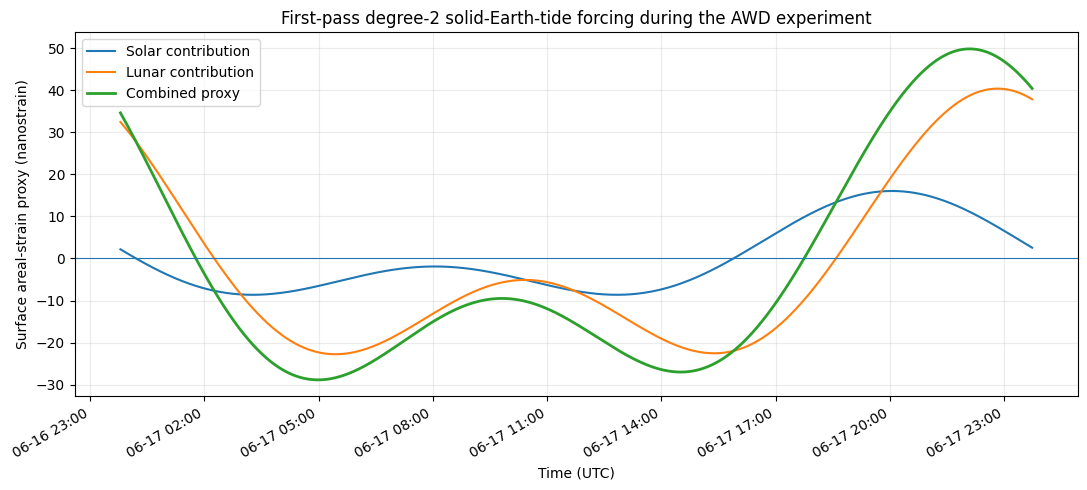

In [ ]:

from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time_array = np.array(times)

plt.figure(figsize=(11, 5))
plt.plot(time_array, tide['sun_strain'] * 1e9, label='Solar contribution')
plt.plot(time_array, tide['moon_strain'] * 1e9, label='Lunar contribution')
plt.plot(time_array, total_strain * 1e9, label='Combined proxy', linewidth=2)
plt.axhline(0.0, linewidth=0.8)
plt.ylabel('Surface areal-strain proxy (nanostrain)')
plt.xlabel('Time (UTC)')
plt.title('First-pass degree-2 solid-Earth-tide forcing during the AWD experiment')
plt.legend()
plt.grid(alpha=0.25)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=3))
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%m-%d %H:%M', tz=timezone.utc)
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
Path('figures').mkdir(exist_ok=True)
plt.savefig('figures/solid_earth_tide_forcing.png', dpi=200, bbox_inches='tight')
plt.show()

### Saved tide-forcing figure

![First-pass degree-2 solid-Earth-tide forcing](figures/solid_earth_tide_forcing.png)


The calculated peak-to-peak variation is of order \(8\times10^{-8}\), or roughly 79 nanostrain. That is a plausible solid-Earth-tide strain scale.

The plotted curve provides approximate forcing timing. It should not be translated directly into a signed SAFOD \(dv/v\) curve because the required stress tensor, depth dependence, propagation geometry, fracture orientation, and constitutive sensitivity are not calculated here.


# 4. SAFOD-relevant velocity-response benchmark from Niu et al. (2008)

Niu et al. inferred a velocity sensitivity to barometric stress of approximately

$$
S_\sigma
=
2.4 \times 10^{-7}\ {\rm Pa}^{-1}.
$$

They also reported a calculated solid-Earth-tide stress variation within approximately

$$
\Delta\sigma_{\rm tide}
\sim
240\ {\rm Pa}.
$$

Their product gives a useful order-of-magnitude SAFOD reference:

$$
\left|
\frac{\delta v}{v}
\right|_{\rm Niu\ scale}
\sim
S_\sigma\,\Delta\sigma_{\rm tide}
=
\left(2.4 \times 10^{-7}\ {\rm Pa}^{-1}\right)
\left(240\ {\rm Pa}\right)
=
5.76 \times 10^{-5}.
$$

This is not an exact prediction for June 2026. The 240 Pa value applies to Niu et al.'s observing interval and their stress calculation, while the coefficient was inferred from barometric loading. The value is used only as a **site-relevant scale**.

The old version of this notebook also plotted a Takano et al. (2014) curve. That curve is removed from the main analysis because it applied a shallow volcanic-site sensitivity to a surface areal-strain proxy at SAFOD, mixing strain definitions, materials, depth, frequency, and wave type. It may be mentioned as literature context, but it is not a defensible SAFOD prediction.

**Interpretive clarification:** Niu et al. did not report extracting a tidal component from their delay-time series. The 240 Pa calculation was used to show that the expected tidal response should be below their measurement error.

In [ ]:

import pandas as pd

AWD_NULL_95 = 3.25e-3
AWD_RELIABLE_TESTED = 1.0e-2
N_PAIRED_BURSTS = 46
AWD_IDEAL_46_STACK = AWD_NULL_95 / np.sqrt(N_PAIRED_BURSTS)

NIU_STRESS_SENSITIVITY = 2.4e-7
NIU_TIDAL_STRESS_SCALE = 240.0
NIU_TIDAL_DV_OVER_V = NIU_STRESS_SENSITIVITY * NIU_TIDAL_STRESS_SCALE

comparison = pd.DataFrame(
    {
        'Quantity': [
            'Smallest tested level with ≥95% correct-sign recovery',
            'Single-burst empirical 95% null threshold',
            'Idealized 46-stack null projection',
            'Niu SAFOD tidal-response scale',
        ],
        'Fractional change': [
            AWD_RELIABLE_TESTED,
            AWD_NULL_95,
            AWD_IDEAL_46_STACK,
            NIU_TIDAL_DV_OVER_V,
        ],
    }
)
comparison['Percent'] = 100.0 * comparison['Fractional change']

try:
    display(
        comparison.style.format(
            {
                'Fractional change': '{:.3e}',
                'Percent': '{:.5f}',
            }
        )
    )
except NameError:  # headless execution outside Jupyter
    print(comparison.to_string(index=False))

print(
    'Niu scale below single-burst null threshold by factor: '
    f'{AWD_NULL_95 / NIU_TIDAL_DV_OVER_V:.1f}'
)
print(
    'Niu scale below reliable tested level by factor: '
    f'{AWD_RELIABLE_TESTED / NIU_TIDAL_DV_OVER_V:.1f}'
)
print(
    'Niu scale below idealized 46-stack projection by factor: '
    f'{AWD_IDEAL_46_STACK / NIU_TIDAL_DV_OVER_V:.1f}'
)

ideal_n_required = (AWD_NULL_95 / NIU_TIDAL_DV_OVER_V) ** 2
print(
    'Ideal white-noise independent-stack count needed to reach '
    f'the Niu scale: approximately {ideal_n_required:,.0f}'
)

,Quantity,Fractional change,Percent
0,Smallest tested level with ≥95% correct-sign recovery,1.000e-02,1.00000
1,Single-burst empirical 95% null threshold,3.250e-03,0.32500
2,Idealized 46-stack null projection,4.792e-04,0.04792
3,Niu SAFOD tidal-response scale,5.760e-05,0.00576


Niu scale below single-burst null threshold by factor: 56.4
Niu scale below reliable tested level by factor: 173.6
Niu scale below idealized 46-stack projection by factor: 8.3
Ideal white-noise independent-stack count needed to reach the Niu scale: approximately 3,184


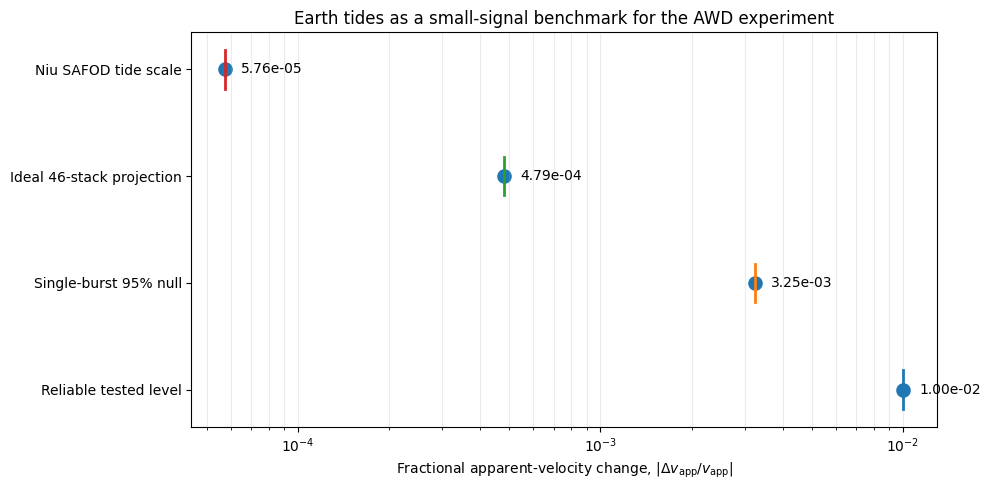

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt


labels = [
    'Reliable tested level',
    'Single-burst 95% null',
    'Ideal 46-stack projection',
    'Niu SAFOD tide scale',
]
values = [
    AWD_RELIABLE_TESTED,
    AWD_NULL_95,
    AWD_IDEAL_46_STACK,
    NIU_TIDAL_DV_OVER_V,
]

y = np.arange(len(labels))

plt.figure(figsize=(10, 5))
plt.scatter(values, y, s=90)
for yi, value in zip(y, values):
    plt.plot([value, value], [yi - 0.18, yi + 0.18], linewidth=2)
    plt.text(value * 1.13, yi, f'{value:.2e}', va='center')
plt.xscale('log')
plt.yticks(y, labels)
plt.xlabel(r'Fractional apparent-velocity change, $|\Delta v_{\rm app}/v_{\rm app}|$')
plt.title('Earth tides as a small-signal benchmark for the AWD experiment')
plt.grid(axis='x', which='both', alpha=0.25)
plt.tight_layout()
Path('figures').mkdir(exist_ok=True)
plt.savefig('figures/awd_tide_sensitivity_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### Saved AWD–tide sensitivity comparison

![AWD sensitivity compared with the Niu SAFOD tide benchmark](figures/awd_tide_sensitivity_comparison.png)

_Nano observable only; superseded by section 7, which adds the Deep guided mode and replaces this threshold comparison with a direct tidal regression._

## Interpretation

The comparison supports a simple, strong conclusion:

> **The expected SAFOD-scale tidal velocity response is far below the current AWD apparent-moveout sensitivity.**

The idealized 46-stack value assumes independent, white, identically distributed errors that decrease exactly as

$$
N^{-1/2}.
$$

That assumption is optimistic because source and coupling systematics need not average away. It should be presented as an experimental-design projection, not a demonstrated threshold.

Under the same idealized scaling, reaching the Niu-scale response from the measured single-burst null width would require roughly

$$
3.2 \times 10^3
$$

statistically independent burst stacks. The actual requirement could be larger or unattainable if systematic source variability dominates.


# 5. How this could be presented

## Main claim

The tide comparison belongs in a section on **time-lapse sensitivity**, not in a section claiming that either the AWD experiment or Niu et al. carried out a dedicated tide search.

A suitable sequence is:

1. show the individual-drop and burst repeatability hierarchy;
2. show the blind injection–recovery result;
3. compare the empirical threshold with a SAFOD-relevant tide scale;
4. conclude that the current AWD design is suited to percent-to-subpercent changes in the selected apparent-moveout observable, but not to a Niu-scale tidal response.

## Suggested paragraph

Although the accelerated weight drop was repeated throughout the 24-hour experiment, individual impacts exhibit measurable timing, amplitude, and SNR variability. Stacking produces a highly repeatable coherent moveout waveform, but blind injection–recovery tests show that the empirical two-sided 95% zero-change threshold is

$$
\left|
\frac{\Delta v_{\rm app}}{v_{\rm app}}
\right|
=
3.25 \times 10^{-3},
$$

and that

$$
\left|
\frac{\Delta v_{\rm app}}{v_{\rm app}}
\right|
=
1.0 \times 10^{-2}
$$

is the smallest tested change recovered with at least 95% correct-sign probability in both directions. For comparison, combining the SAFOD stress sensitivity and tidal-stress scale reported by Niu et al. (2008) gives a characteristic tidal velocity response of

$$
\left|
\frac{\delta v}{v}
\right|_{\rm Niu\ scale}
=
5.76 \times 10^{-5}.
$$

This response is well below the demonstrated sensitivity of the present AWD experiment. We therefore use solid-Earth tides as a small-signal benchmark for experimental design rather than interpret 24-hour-timescale delay variations as a detected tidal response.

## A one-sentence summary

> We modeled the tide only to place a physically relevant small signal on the same scale as the empirical AWD injection–recovery limit. This follows the logic of Niu et al. (2008), who used the modeled tide as a detectability check and concluded that the expected response was below their precision.


# 6. What should not be claimed

- Do not say that the notebook predicts the exact June 2026 fault-normal tidal stress.
- Do not convert the surface areal-strain proxy directly into a signed \(dv/v\) time series.
- Do not describe the ideal 46-stack \(N^{-1/2}\) curve as a measured detection limit.
- Do not use the Takano volcanic-site sensitivity as expected SAFOD behavior.
- Do not label the phase-free 24-hour regression or CCA as a tide detection.
- Do not say that no tidal response exists; say that the expected response lies below the demonstrated sensitivity.

If a precision tidal model later becomes scientifically necessary, the next step is a validated site- and depth-specific strain/stress calculation with ocean loading and a documented projection onto the relevant ray path or fault orientation. That calculation is unnecessary for the present detectability argument.

---

# 7. Update, 2026-08-06 — the Deep guided mode, and a direct tidal fit

**This section supersedes the Nano-only numbers in sections 2 and 4 above.** Those
remain correct for the Nano observable; they were simply the only measurement
available when this notebook was written.

Two things have changed. A blind injection–recovery test now exists for the Deep
guided mode, and the solid-Earth-tide comparison has been replaced by an actual
regression rather than a threshold comparison.

## 7.1 The Deep guided mode is about twice as sensitive as Nano

Measured on 23 held-out bursts at 15–30 Hz, with the estimator and injection grid
imported from the Nano analysis so the two are comparable by construction:

| Observable | 95% null threshold | Reliable detection level |
|---|---|---|
| Nano apparent moveout (46 bursts) | 3.25×10⁻³ | 1×10⁻² |
| **Deep outbound** (23 held out) | **1.84×10⁻³** | **5×10⁻³** |
| Deep return | 3.05×10⁻³ | 1×10⁻² |
| Deep paired, covariance-aware | 1.67×10⁻³ | 5×10⁻³ |

The claim is restricted to the outbound branch: the return leg equals Nano rather
than beating it.

Importantly, the improvement is far smaller than the geometry alone predicts. The
Deep outbound regression has 11.5× Nano's lever arm in travel time, but only ~2×
the sensitivity, because Deep's per-burst timing repeatability is 7.4× worse
(1.68 ms against 0.225 ms) and consumes four fifths of the geometric advantage.

Revised gap to the Niu SAFOD tide scale of 5.76×10⁻⁵:

| | gap | independent bursts needed |
|---|---|---|
| Nano | 56× | ~3,180 |
| Deep outbound | 32× | ~1,020 |

The experiment collected 46. The Deep observable cuts the required stacking
roughly threefold and remains about 20× short.

## 7.2 A direct tidal regression, not a threshold comparison

Section 4 compared a sensitivity threshold against a tide scale. That comparison
can now be replaced by fitting the tide model in section 3 directly to the
per-burst velocity estimates, since the zero-injection trials already constitute
a dv/v time series. The fit includes a constant and a linear trend, because over a
22-hour window the diurnal tidal shape is not orthogonal to instrumental drift.
Inference is by surrogate null: 999 random time shifts of the tide predictor.

![Deep guided-mode tidal regression](awd_clean/deep_dvv_tidal_fit.png)

| Observable | Amplitude | σ | p (surrogate) | 95% UL | ×De Fazio |
|---|---|---|---|---|---|
| Deep outbound | +3.64×10⁻⁴ | 4.58×10⁻⁴ | 0.576 | 1.26×10⁻³ | 2.52 |
| Deep return | +6.85×10⁻⁴ | 7.23×10⁻⁴ | 0.378 | 2.10×10⁻³ | 4.20 |
| Deep paired, inverse-variance | +4.60×10⁻⁴ | 4.02×10⁻⁴ | 0.517 | **1.25×10⁻³** | **2.50** |
| Deep paired, covariance-aware | +4.62×10⁻⁴ | 4.08×10⁻⁴ | 0.476 | 1.26×10⁻³ | 2.52 |

Every p-value is a clean null. No tidal signal is detected, and none is claimed.
Fitted amplitudes (+3.6 to +6.9×10⁻⁴) sit close to Paper 1's Nano value of
+3.4×10⁻⁴, and the p-values close to its 0.51.

## 7.3 The better observable does not buy a better tidal limit

The Deep 95% upper limit is 1.25×10⁻³, or **2.5× the De Fazio scale** — larger
than Paper 1's Nano limit of 7.98×10⁻⁴ (1.6×), not smaller.

This was not expected. A scatter-ratio projection from the improved per-burst
precision suggested the Deep limit might reach ~0.67× De Fazio. It does not, for
two reasons:

1. **Burst count.** This fit uses the 23 held-out bursts; Paper 1 used 46. That
   alone is a √2 penalty.
2. **Drift degeneracy.** The tidal amplitude uncertainty is ~1.5× larger than
   per-burst scatter predicts, because the diurnal tidal shape is not orthogonal
   to instrumental drift over a 22-hour record.

Repeating the fit on all 46 bursts settles this by measurement rather than
scaling. The best upper limit becomes 1.03×10⁻³ (2.05× De Fazio), not the
8.8×10⁻⁴ a √N scaling predicted: doubling the burst count bought only 1.21×,
because σ fell from 4.02 to 3.13×10⁻⁴ while the amplitude did not move.
**At matched burst count the Deep tidal limit remains ~1.3× worse than Paper
1's 7.98×10⁻⁴**, despite Deep's better per-burst precision.

The conclusion of this notebook is therefore unchanged and strengthened: the
expected SAFOD-scale tidal velocity response lies well below what this experiment
can resolve, and that remains true for the more sensitive of the two observables.
A 24-hour survey is the binding constraint as much as the observable is.

## 7.4 Additions to "what should not be claimed"

Carrying forward section 6, and adding:

- Do not state that the Deep installation outperforms Nano. Only the outbound
  branch does; the return leg matches Nano.
- Do not quote the Deep tidal upper limit as a formation Vp or Vs limit. It bounds
  an apparent guided-mode velocity change and carries no depth resolution.
- Do not compare the Deep upper limit to Paper 1's without noting the differing
  burst counts and processing chains. This regression is the same *style* as Paper
  1's registered null, not a re-run of it.
- Do not describe the improved Deep precision as implying an improved tidal
  sensitivity. It does not, and the reason — drift degeneracy over a 24-hour
  window — is itself worth reporting.

Sources: `awd_clean/deep_dvv_tidal_fit.py`, `awd_clean/DEEP_DVV_STATUS.md`,
`awd_clean/DEEP_DVV_PREREGISTRATION.md`.


# References used for interpretation

- De Fazio, T. L., Aki, K., & Alba, J. (1973). *Solid Earth Tide and Observed Change in the In Situ Seismic Velocity*. Journal of Geophysical Research, 78, 1319–1322.
- Métivier, L., & Conrad, C. P. (2008). *Body tides of a convecting, laterally heterogeneous, and aspherical Earth*. Journal of Geophysical Research: Solid Earth, 113, B11405.
- Niu, F., Silver, P. G., Daley, T. M., Cheng, X., & Majer, E. L. (2008). *Preseismic velocity changes observed from active source monitoring at the Parkfield SAFOD drill site*. Nature, 454, 204–208.
- Takano, T., Nishimura, T., Nakahara, H., Ohta, Y., & Tanaka, S. (2014). *Seismic velocity changes caused by the Earth tide: Ambient noise correlation analyses of small-array data*. Geophysical Research Letters, 41, 6131–6136. Included as context only; not used as a SAFOD prediction.
